# **1. Iris Flower Classification**

Objective: Classify iris flowers into three species (Setosa, Versicolor, Virginica) based on
measurements of their petals and sepals.<br>

<t>
Dataset: The classic Iris dataset from UCI Repository or scikit-learn.<br>
<br>
Steps:<br>
o Load the dataset and explore it visually (scatter plots or histograms).<br>
o Split the data into training/test sets.<br>
o Preprocess if needed (usually, it's already clean).<br>
o Train a simple classifier (e.g., Logistic Regression, K-Nearest Neighbors, Decision
Tree).<br>
o Evaluate with accuracy, precision, or confusion matrix.<br>
 Skills gained: Numeric data analysis, classification modeling, evaluating results.<br>

## **Load the datasets and import the libraries**

**I'm not importing all the libraries in one go so make note of that** <br>

I'll use sklearn for the entirity <br>
and will mostly use pickel to upload the model

In [2]:
from sklearn import datasets
import pandas as pd

In [3]:
data=datasets.load_iris()

In [4]:
print(data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

## **Split the Data-set** 

**since the dataset is alread splitted into features and labels im not going to split into x and y**

In [5]:
features=pd.DataFrame(data.data,columns=data.feature_names)
labels=pd.DataFrame(data.target,columns=['species'])

In [6]:
features

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
labels

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


## **Data Statistics**

In [8]:
features.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [9]:
labels.isnull().sum()

species    0
dtype: int64

no NaNs so just moving forward

### **DAta evaluation --**

using matplot and seaborn for visualization

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

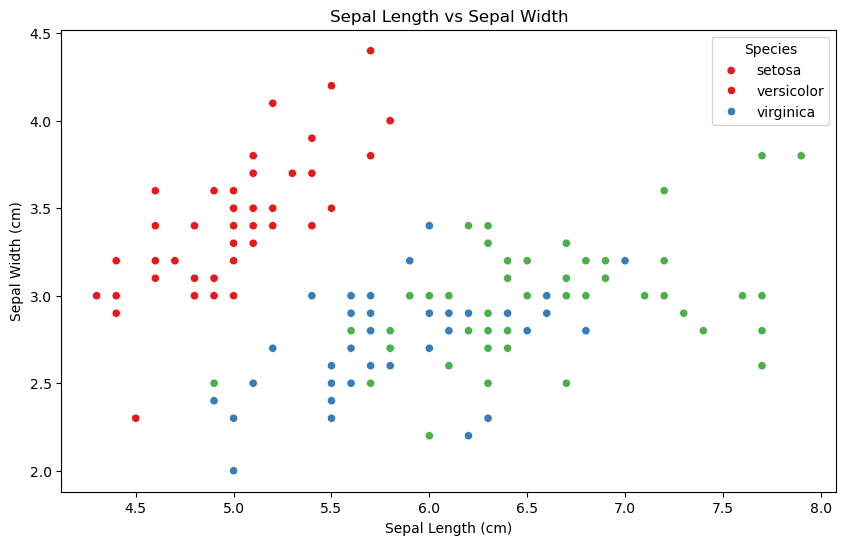

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=features['sepal length (cm)'],y=features['sepal width (cm)'],hue=labels['species'],palette='Set1')
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species', labels=data.target_names)   

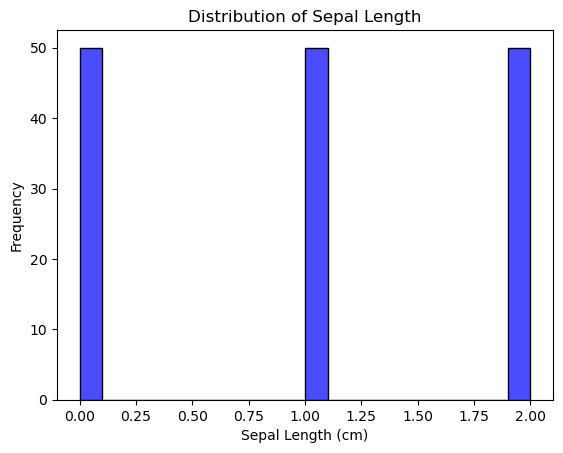

In [17]:
sns.histplot(labels['species'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.show()

In [37]:
features.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [38]:
labels.describe()

,species
count,150.000000
mean,1.000000
std,0.819232
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


the data looks okay so moving on

for my convinience im splitting into x and y

In [18]:
x,y=features,labels

In [19]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [20]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


## **Splitting into test and train**

In [22]:
from sklearn.model_selection import train_test_split as tts

In [23]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [28]:
x_train.shape

(120, 4)

In [27]:
x_test.shape


(30, 4)

## **Model: Random Forest Classifier**

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

/opt/anaconda3/envs/tf2.18/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [31]:
test_pred=rf.predict(x_test)
train_pred=rf.predict(x_train)

In [32]:
train_pred

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

In [43]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [46]:
accuracy=accuracy_score(y_test,test_pred)
class_report=classification_report(y_test,test_pred)
conf_matrix=confusion_matrix(y_test,test_pred)

In [47]:
accuracy

1.0

In [48]:
class_report

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         9\n           2       1.00      1.00      1.00        11\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n'

In [49]:
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [39]:
features.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [40]:
length=int(input("Enter sepal length in cm: "))
width=int(input("Enter sepal width in cm: "))
p_length=int(input("Enter petal length in cm: "))
p_width=int(input("Enter petal width in cm: "))

In [42]:
data=[length,width,p_length,p_width]
data

[5, 4, 3, 2]

In [51]:
test=rf.predict([data])

/opt/anaconda3/envs/tf2.18/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [53]:
if test ==1:
    print("The flower is Iris Versicolor")
elif test==0:
    print("The flower is Iris Setosa")
else:
    print("The flower is Iris Virginica")

The flower is Iris Versicolor
